In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pickle
import seaborn as sns
from datetime import datetime
import numpy as np
from collections import Counter
import itertools
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, ConfusionMatrixDisplay, precision_recall_curve

In [89]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Data Load and Clean**

In [90]:
# Load the uploaded dataset
file_path = "/content/drive/MyDrive/big_startup_secsees_dataset.csv"
df = pd.read_csv(file_path)

In [91]:
# Display basic information about the dataset
df_info = df.info()
df_head = df.head()
df_columns = df.columns.tolist()

df_info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66368 entries, 0 to 66367
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   permalink          66368 non-null  object
 1   name               66367 non-null  object
 2   homepage_url       61310 non-null  object
 3   category_list      63220 non-null  object
 4   funding_total_usd  66368 non-null  object
 5   status             66368 non-null  object
 6   country_code       59410 non-null  object
 7   state_code         57821 non-null  object
 8   region             58338 non-null  object
 9   city               58340 non-null  object
 10  funding_rounds     66368 non-null  int64 
 11  founded_at         51147 non-null  object
 12  first_funding_at   66344 non-null  object
 13  last_funding_at    66368 non-null  object
dtypes: int64(1), object(13)
memory usage: 7.1+ MB


In [92]:
df_head

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24


In [93]:
df.describe()

,funding_rounds
count,66368.000000
mean,1.732522
std,1.360251
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,19.000000


In [94]:
# Clean and preprocess key columns for EDA
df_clean = df.copy()

In [95]:
# Replace '-' or missing with NaN in funding
df_clean['funding_total_usd'] = df_clean['funding_total_usd'].replace('-', np.nan)
df_clean['funding_total_usd'] = df_clean['funding_total_usd'].astype(float)

In [96]:
# Drop rows with null status or funding_total_usd
df_clean = df_clean.dropna(subset=['status', 'funding_total_usd'])

In [97]:
# Create a simplified binary success label
# success = 1 if acquired or IPO, fail = 0 if closed, else 'operating' left out for now
df_clean['success_binary'] = df_clean['status'].apply(lambda x: 1 if x.lower() in ['acquired', 'ipo'] else (0 if x.lower() == 'closed' else np.nan))

In [98]:
# Filter only for clear success/failure
df_bin = df_clean.dropna(subset=['success_binary'])

# **EDA Analysis**

**1. Distribution of Startup Statuses**

This graph shows the distribution of startup statuses. The tallest bar represents "operating," meaning most startups are still running. The next bar is "closed," showing many startups have shut down. The third bar is "acquired," indicating some were bought by other companies. The last bar, "IPO," is the shortest, meaning very few startups went public. Overall, most startups are operating, while few achieve an IPO.

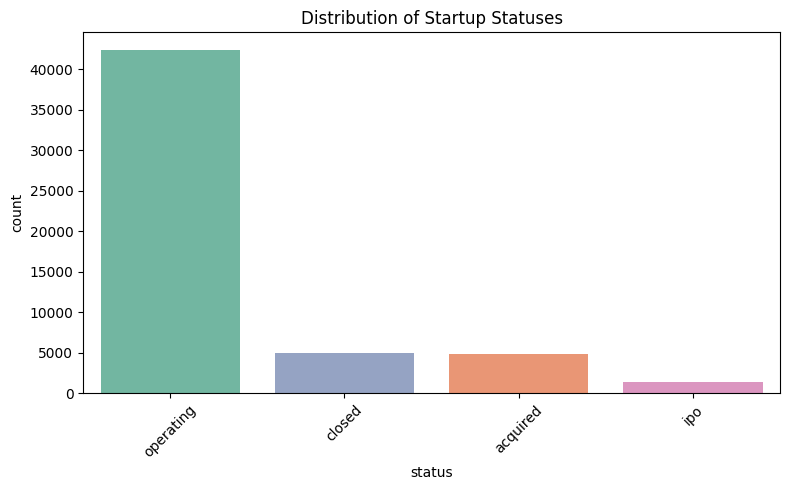

In [99]:
# Plot 1: Distribution of Startup Statuses
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='status', order=df_clean['status'].value_counts().index,palette='Set2', hue='status', legend=False )
plt.title('Distribution of Startup Statuses')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**2. Funding Distribution**

This graph shows how much funding startups received, focusing on amounts under 50 million.The tallest bar is at "0" USD meaning many startups got no funding. As funding increases, the number of startups drops sharply. Very few startups received between $40-$50 million. In short, most startups get little or no funding, and only a small number secure larger investments.

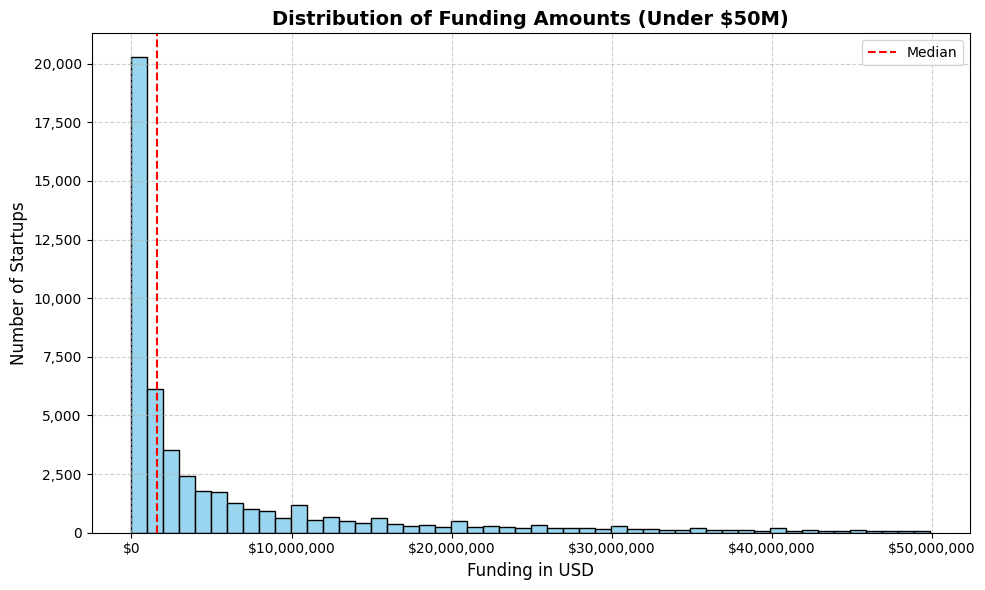

In [100]:
# Temporary conversion just for plotting
# Handle non-numeric values by coercing them to NaN
funding_numeric = pd.to_numeric(df['funding_total_usd'], errors='coerce')
# Filter for values under $50M and drop NaN values
filtered_data = funding_numeric[(funding_numeric < 5e7) & (funding_numeric.notna())]

plt.figure(figsize=(10,6))
sns.histplot(filtered_data, bins=50, color='skyblue', edgecolor='black', alpha=0.85)
plt.title('Distribution of Funding Amounts (Under $50M)', fontsize=14, fontweight='bold')
plt.xlabel('Funding in USD', fontsize=12)
plt.ylabel('Number of Startups', fontsize=12)
# Format x-axis (USD) and y-axis (comma)
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.axvline(filtered_data.median(), color='red', linestyle='--', label='Median')
plt.legend()
# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**3. Funding Over Time Analysis**

This graph shows how total startup funding has changed over the years, measured in millions of USD. The funding amounts range from $0 to $100,000 million. The lowest point is around year 2000, indicating less investment in startups at that time. The highest point reaches $100,000 million, showing a big increase in funding in later years. Overall, startup funding has grown significantly over time.

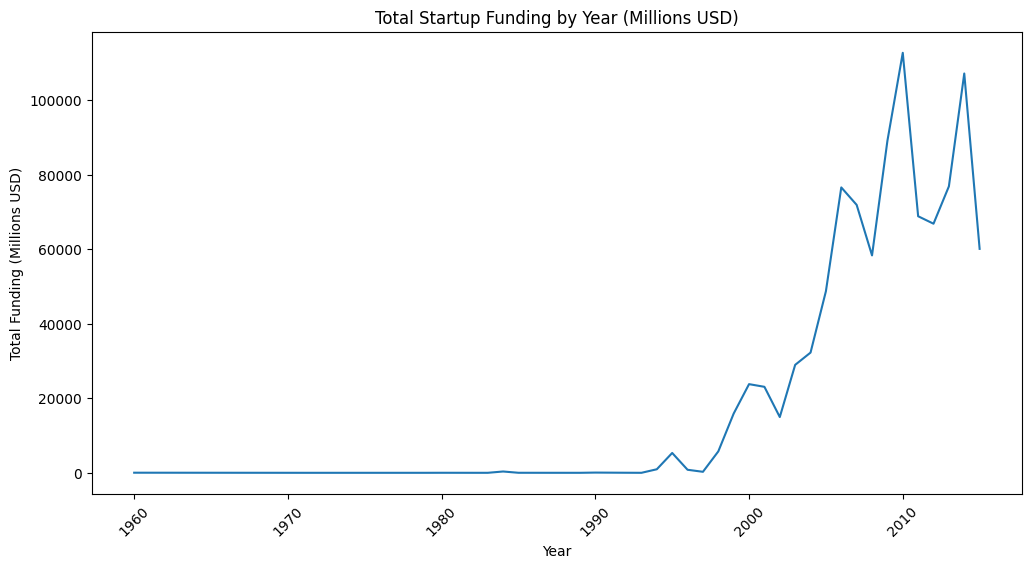

In [101]:
# 1. Convert funding amount to numeric first (to fix the division error)
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors='coerce')

# 2. Convert dates with error handling
df['first_funding_at'] = pd.to_datetime(df['first_funding_at'], errors='coerce')
df['last_funding_at'] = pd.to_datetime(df['last_funding_at'], errors='coerce')

# 3. Create a clean copy to avoid SettingWithCopyWarning
clean_df = df.copy()

# 4. Add year columns using .loc to avoid warnings
clean_df.loc[:, 'first_funding_year'] = clean_df['first_funding_at'].dt.year
clean_df.loc[:, 'last_funding_year'] = clean_df['last_funding_at'].dt.year

# 5. Filter out invalid dates and funding amounts
valid_data = clean_df[
    (clean_df['first_funding_at'].notna()) &
    (clean_df['last_funding_at'].notna()) &
    (clean_df['funding_total_usd'].notna())
]

# 6. Plot funding trends
plt.figure(figsize=(12,6))
funding_by_year = valid_data.groupby('first_funding_year')['funding_total_usd'].sum()
sns.lineplot(
    x=funding_by_year.index,
    y=funding_by_year.values/1e6  # Now safe to divide since we converted to numeric
)
plt.title('Total Startup Funding by Year (Millions USD)')
plt.xlabel('Year')
plt.ylabel('Total Funding (Millions USD)')
plt.xticks(rotation=45)
plt.show()

**4.Funding Rounds Analysis**

This box plot shows the relationship between the number of funding rounds a startup goes through and its total funding (in USD, using a log scale). The correlation of 0.11 is very weak, meaning there’s almost no link between how many rounds a startup raises and how much total funding it gets. Some startups raise a lot in few rounds, while others raise little over many rounds.

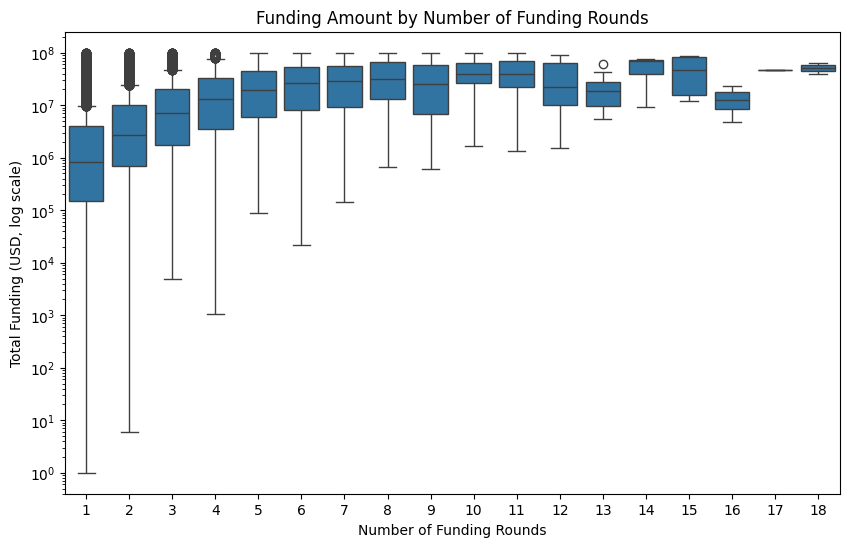

Correlation between funding rounds and total funding: 0.11


In [102]:
# Relationship between funding rounds and total funding
plt.figure(figsize=(10,6))
sns.boxplot(x='funding_rounds', y='funding_total_usd', data=df[df['funding_total_usd'] < 1e8])
plt.yscale('log')
plt.title('Funding Amount by Number of Funding Rounds')
plt.xlabel('Number of Funding Rounds')
plt.ylabel('Total Funding (USD, log scale)')
plt.show()

# Correlation between rounds and funding
print(f"Correlation between funding rounds and total funding: {df['funding_rounds'].corr(df['funding_total_usd']):.2f}")

# **5. Top Categories**

This bar graph ranks the top 10 startup categories by the number of startups in each. "Software" has the highest count (likely near 8000), making it the most popular category. Mobile, Biotechnology, and E-Commerce follow closely. Less common categories like Games and Advertising appear at the bottom. The graph shows that tech-focused fields dominate, with Software and Mobile leading the startup landscape.

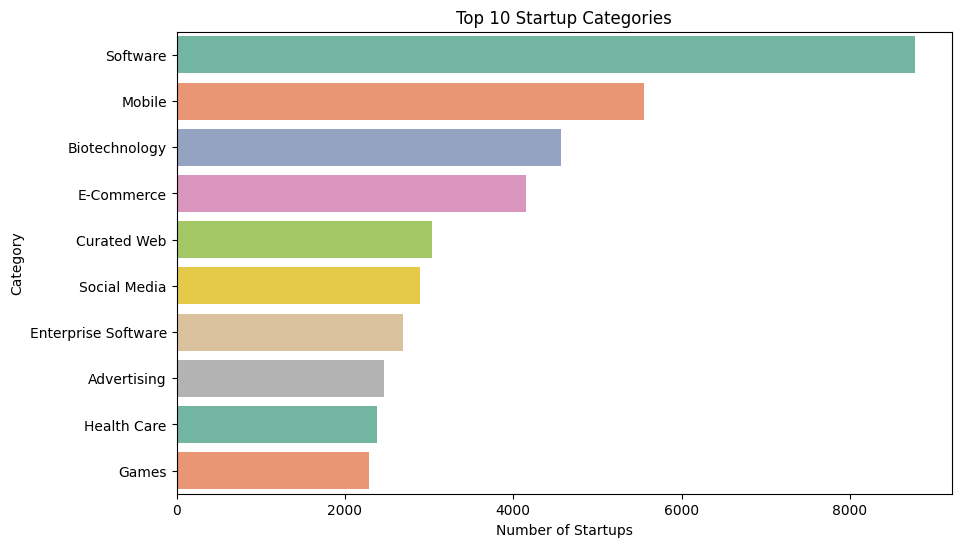

In [103]:
# Split category lists and count occurrences
all_categories = list(itertools.chain(*df['category_list'].str.split('|').dropna()))
top_categories = pd.Series(Counter(all_categories)).sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_categories.values,
    y=top_categories.index,
    hue=top_categories.index,        # Assign y-values to hue
    palette='Set2',
    legend=False                     # Turn off legend as it's redundant
)
plt.title('Top 10 Startup Categories')
plt.xlabel('Number of Startups')
plt.ylabel('Category')
plt.show()

**6.Category Funding Analysis**

This bar graph shows the top 10 highest-funded startup categories based on average funding in millions of USD. "Limousines" leads with the highest average funding (likely near 800 million), followed by niche sectors like Space Travel and B2B Express Delivery. The graph highlights that capital-intensive industries—such as Space Travel and Solar Power—tend to secure much larger investments compared to typical tech startups.

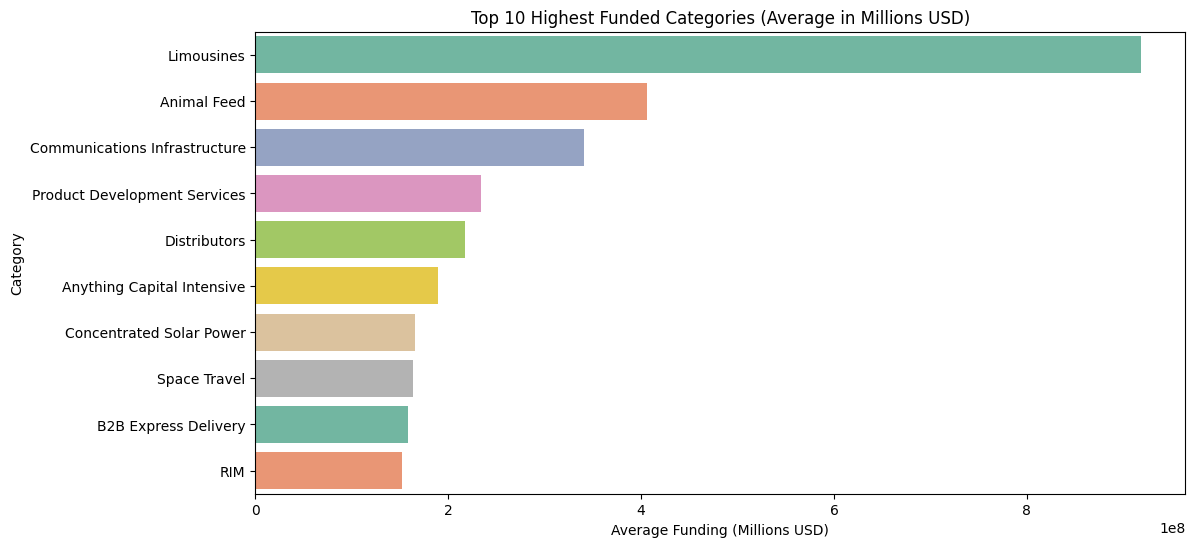

In [104]:
# Calculate average funding by category
category_funding = {}
for category in set(all_categories):
    mask = df['category_list'].str.contains(category, na=False)
    category_funding[category] = df[mask]['funding_total_usd'].mean()

top_funded_categories = pd.Series(category_funding).sort_values(ascending=False).head(10)

# Convert to DataFrame for Seaborn
top_funded_df = top_funded_categories.reset_index()
top_funded_df.columns = ['Category', 'Average_Funding_Million']

# Plot (fixed for Seaborn v0.14+)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_funded_df,
    x='Average_Funding_Million',
    y='Category',
    hue='Category',        # ✅ Assign y as hue
    palette='Set2',
    legend=False           # ✅ Disable redundant legend
)
plt.title('Top 10 Highest Funded Categories (Average in Millions USD)')
plt.xlabel('Average Funding (Millions USD)')
plt.ylabel('Category')
plt.show()

**7.City-Level Analysis (Top 10 Cities)**

This graph compares two key startup metrics by city. The top section shows the number of startups, with San Francisco leading (around 3500), followed by New York and London. The bottom section displays total funding, where San Francisco again dominates (likely near $70 billion), far ahead of New York and Beijing. While some cities have many startups (e.g., Austin), others secure higher total funding (e.g., Beijing), highlighting differences in scale and investment concentration.

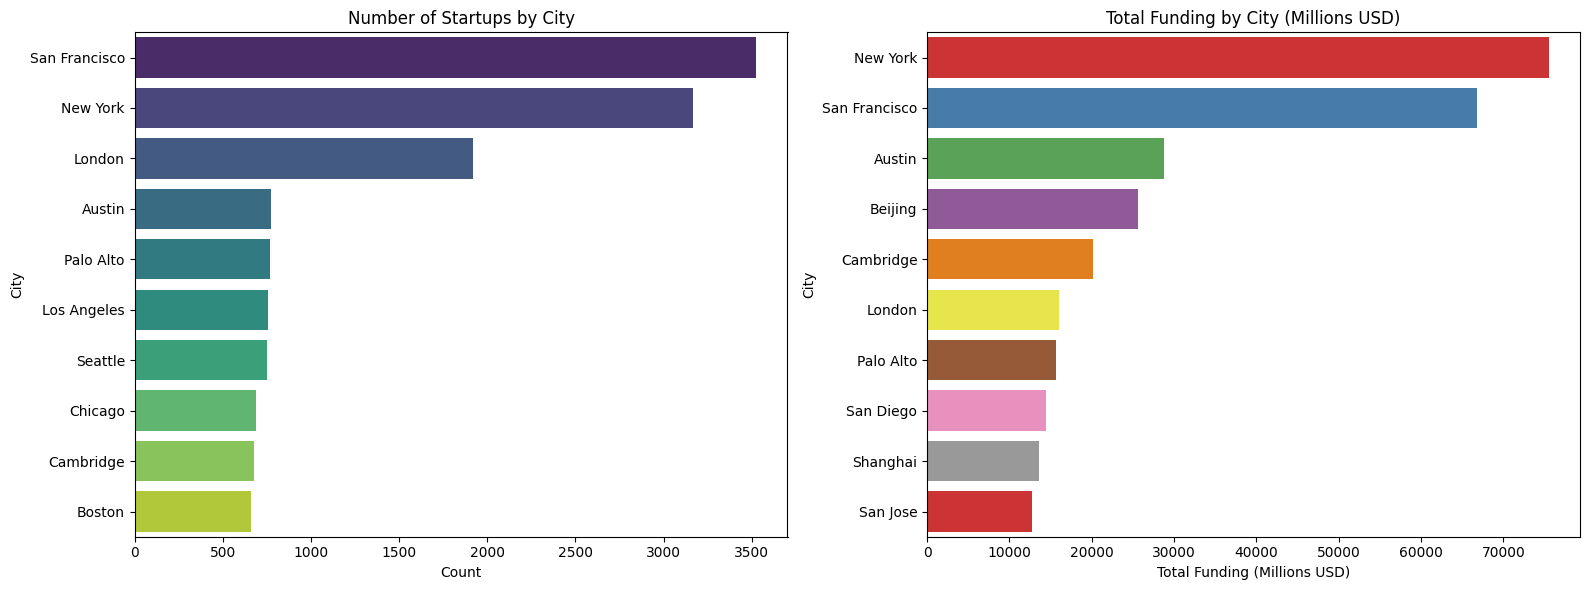

In [105]:
top_cities = df['city'].value_counts().head(10)
city_funding = df.groupby('city')['funding_total_usd'].sum().sort_values(ascending=False).head(10)

# Prepare DataFrames for Seaborn
top_cities_df = top_cities.reset_index()
top_cities_df.columns = ['City', 'Count']

city_funding_df = city_funding.reset_index()
city_funding_df.columns = ['City', 'Total_Funding_Million']
city_funding_df['Total_Funding_Million'] = city_funding_df['Total_Funding_Million'] / 1e6

# Plot with fixed warnings
fig, ax = plt.subplots(1, 2, figsize=(16,6))

# Plot 1: Number of Startups by City
sns.barplot(
    data=top_cities_df,
    x='Count',
    y='City',
    hue='City',        # ✅ Link hue
    palette='viridis',
    legend=False,
    ax=ax[0]
)
ax[0].set_title('Number of Startups by City')
ax[0].set_xlabel('Count')

# Plot 2: Total Funding by City
sns.barplot(
    data=city_funding_df,
    x='Total_Funding_Million',
    y='City',
    hue='City',        # ✅ Link hue
    palette='Set1',
    legend=False,
    ax=ax[1]
)
ax[1].set_title('Total Funding by City (Millions USD)')
ax[1].set_xlabel('Total Funding (Millions USD)')

plt.tight_layout()
plt.show()

#  **Feature Engineering**

I performed feature engineering to create new, meaningful information from the existing data that can help my machine learning models better understand and predict whether a startup will succeed or fail. Raw data alone is often not enough, so I calculated useful features like startup age, time to get first funding, funding per year, and average funding per round. These give us insights into how quickly and how much a startup is funded. I also grouped sectors and highlighted popular ones to make trends easier to spot. These engineered features help improve the accuracy and explainability of my prediction models.


In [106]:
# Make a copy of the filtered dataset
df_bin = df_clean.dropna(subset=['success_binary']).copy()

# Convert date columns to datetime
df_bin['founded_at'] = pd.to_datetime(df_bin['founded_at'], errors='coerce')
df_bin['first_funding_at'] = pd.to_datetime(df_bin['first_funding_at'], errors='coerce')
df_bin['last_funding_at'] = pd.to_datetime(df_bin['last_funding_at'], errors='coerce')

# Today's reference date
today = pd.Timestamp(datetime.today())

# 1. Startup Age (in years)
df_bin['startup_age'] = (today - df_bin['founded_at']).dt.days / 365

# 2. Funding Duration (days)
df_bin['funding_duration'] = (df_bin['last_funding_at'] - df_bin['first_funding_at']).dt.days

# 3. Time to First Funding (days)
df_bin['time_to_first_funding_days'] = (df_bin['first_funding_at'] - df_bin['founded_at']).dt.days

# 4. Funding per Round
df_bin['funding_per_round'] = df_bin['funding_total_usd'] / df_bin['funding_rounds']
df_bin['funding_per_round'] = df_bin['funding_per_round'].replace([np.inf, -np.inf], np.nan)

# 5. Total Funding Per Year
df_bin['funding_per_year'] = df_bin['funding_total_usd'] / df_bin['startup_age']
#df_bin['funding_per_year'].replace([np.inf, -np.inf], np.nan, inplace=True)
df_bin['funding_per_year'] = df_bin['funding_per_year'].replace([np.inf, -np.inf], np.nan)

# 6. Funding Rounds Per Year
df_bin['funding_rounds_per_year'] = df_bin['funding_rounds'] / df_bin['startup_age']
#df_bin['funding_rounds_per_year'].replace([np.inf, -np.inf], np.nan, inplace=True)
df_bin['funding_rounds_per_year'] = df_bin['funding_rounds_per_year'].replace([np.inf, -np.inf], np.nan)

# 7. Primary Sector
df_bin['sector_main'] = df_bin['category_list'].astype(str).apply(lambda x: x.split('|')[0] if '|' in x else x)

# 8. Sector Popularity (frequency encoding)
sector_counts = df_bin['sector_main'].value_counts()
df_bin['sector_popularity'] = df_bin['sector_main'].map(sector_counts)

# 9. Group Rare Sectors as "Other"
rare_threshold = 50
df_bin['sector_grouped'] = df_bin['sector_main'].apply(lambda x: x if sector_counts[x] >= rare_threshold else 'Other')

# 10. USA Indicator
df_bin['is_USA'] = df_bin['country_code'].apply(lambda x: 1 if x == 'USA' else 0)


In [107]:
# List of all 10 engineered features
engineered_columns = [
    'startup_age',
    'funding_duration',
    'time_to_first_funding_days',
    'funding_per_round',
    'funding_per_year',
    'funding_rounds_per_year',
    'sector_main',
    'sector_popularity',
    'sector_grouped',
    'is_USA'
]

# Display the first 10 rows of these columns
df_bin[engineered_columns].head(10)

,startup_age,funding_duration,time_to_first_funding_days,funding_per_round,funding_per_year,funding_rounds_per_year,sector_main,sector_popularity,sector_grouped,is_USA
15,13.498630,0.0,1111.0,5000000.0,3.704080e+05,0.074082,Apps,180,Apps,1
20,16.663014,0.0,134.0,500000.0,3.000658e+04,0.060013,Art,13,Other,1
23,15.167123,411.0,-181.0,1267500.0,1.671378e+05,0.131864,Curated Web,584,Curated Web,1
31,13.956164,28.0,47.0,625000.0,8.956616e+04,0.143306,Analytics,255,Analytics,1
32,25.671233,0.0,3719.0,35000000.0,1.363394e+06,0.038954,Software,888,Software,1
34,16.416438,0.0,0.0,50000.0,3.045728e+03,0.060915,Curated Web,584,Curated Web,1
47,NaN,0.0,NaN,1800000.0,NaN,NaN,Enterprise Software,336,Enterprise Software,1
67,15.663014,0.0,896.0,700000.0,4.469127e+04,0.063845,Augmented Reality,5,Other,0
76,16.295890,0.0,17.0,50000.0,3.068258e+03,0.061365,Entertainment,73,Entertainment,1
80,35.676712,0.0,4488.0,14000000.0,3.924128e+05,0.028029,Software,888,Software,1


# **Train Models**

In [108]:
# Select features and target
features = [
    'startup_age', 'funding_duration', 'time_to_first_funding_days',
    'funding_per_round', 'funding_per_year', 'funding_rounds_per_year',
    'sector_popularity', 'is_USA'
]
X = df_bin[features].fillna(df_bin[features].median())
y = df_bin['success_binary']

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Logistic Regression**

We used Logistic Regression as a simple and interpretable model. It helps us understand how each feature (like funding or startup age) affects the chance of success. It’s a great starting point and sets a baseline for comparison. It also provides confidence scores and works well when features are scaled properly.


In [109]:
# Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
cv_lr = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='roc_auc').mean()#Uses ROC-AUC score to evaluate model performance

**Random Forest**

Random Forest was used because it handles complex patterns and interactions between features. It’s great at managing both numerical and categorical data without much preprocessing. It also gives us feature importance, which helps explain what matters most in predicting startup success. It reduces overfitting by combining many decision trees.

In [110]:
# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
cv_rf = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='roc_auc').mean()

**XGBoost**

We chose XGBoost for its excellent performance in real-world data competitions. It uses boosting to improve accuracy and handles missing values and noise well. We tuned its parameters using GridSearch to get better results. It often outperforms other models, especially when working with structured tabular data like ours.

In [111]:
# XGBoost
xgb = XGBClassifier(eval_metric='logloss')
params = {'n_estimators': [100], 'max_depth': [3]}
grid = GridSearchCV(xgb, params, cv=3, scoring='roc_auc')
grid.fit(X_train_scaled, y_train)
xgb_model = grid.best_estimator_
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
cv_xgb = cross_val_score(xgb_model, X_train_scaled, y_train, cv=5, scoring='roc_auc').mean()

In [112]:
pickle.dump(xgb_model, open("xgb_model.pkl", "wb"))
print("Saved Model Type:", type(xgb_model))

Saved Model Type: <class 'xgboost.sklearn.XGBClassifier'>


**SVM**

I used the Support Vector Machine (SVM) model because it works very well with complex and high-dimensional data. It helps find the best line or boundary that separates successful and unsuccessful startups. SVM is powerful for pattern detection and is less likely to overfit. Adding it to the project gives us a different perspective and helps compare performance with other models to choose the most reliable one.


In [113]:
# SVM
svm_model = SVC(probability=True, kernel='rbf', random_state=42).fit(X_train_scaled, y_train)
y_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]
y_pred_svm = svm_model.predict(X_test_scaled)
cv_svm = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring='roc_auc').mean()

**Model Evaluation**

The evaluation function in the code is used to measure how well each model is performing. It takes the model name, actual and predicted values, predicted probabilities, and cross-validation score, then prints several important metrics. These include accuracy (how many predictions were correct), ROC AUC (how well the model separates success vs failure), a confusion matrix (to see errors), and a detailed classification report (including precision, recall, and F1-score). This step is very important in the project because it helps compare different models (Logistic Regression, Random Forest, and XGBoost) and choose the best one based on both performance and consistency.

In [114]:
# Evaluation function
def evaluate_model(name, y_true, y_pred, y_proba, cv_score):
    print(f"\n {name} Results:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("ROC AUC:", roc_auc_score(y_true, y_proba))
    print("CV ROC AUC:", cv_score)
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

In [115]:
# Run evaluations
evaluate_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr, cv_lr)
evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf, cv_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb, y_proba_xgb, cv_xgb)
evaluate_model("SVM", y_test, y_pred_svm, y_proba_svm, cv_svm)


 Logistic Regression Results:
Accuracy: 0.7043517272319426
ROC AUC: 0.771345620328898
CV ROC AUC: 0.7886220209062383
Confusion Matrix:
 [[628 355]
 [304 942]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.67      0.64      0.66       983
         1.0       0.73      0.76      0.74      1246

    accuracy                           0.70      2229
   macro avg       0.70      0.70      0.70      2229
weighted avg       0.70      0.70      0.70      2229


 Random Forest Results:
Accuracy: 0.721399730820996
ROC AUC: 0.7834563992364579
CV ROC AUC: 0.7913653766602801
Confusion Matrix:
 [[620 363]
 [258 988]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.71      0.63      0.67       983
         1.0       0.73      0.79      0.76      1246

    accuracy                           0.72      2229
   macro avg       0.72      0.71      0.71      2229
weighted avg       0.72      0.72      

In [116]:
# Evaluation for all
comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM (RBF)'],
    'Accuracy': [
        accuracy_score(y_test, lr_model.predict(X_test_scaled)) * 100,
        accuracy_score(y_test, rf_model.predict(X_test_scaled)) * 100,
        accuracy_score(y_test, xgb_model.predict(X_test_scaled)) * 100,
        accuracy_score(y_test, y_pred_svm) * 100
    ],
    'ROC AUC': [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb),
        roc_auc_score(y_test, y_proba_svm)
    ],
    'CV ROC AUC': [
        cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='roc_auc').mean(),
        cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='roc_auc').mean(),
        cross_val_score(xgb_model, X_train_scaled, y_train, cv=5, scoring='roc_auc').mean(),
        cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring='roc_auc').mean()
    ]
}
comparison_df = pd.DataFrame(comparison_data)
# Display updated model comparison table
comparison_df

,Model,Accuracy,ROC AUC,CV ROC AUC
0,Logistic Regression,70.435173,0.771346,0.788622
1,Random Forest,72.139973,0.783456,0.791365
2,XGBoost,73.261552,0.807747,0.819052
3,SVM (RBF),72.184836,0.766936,0.790855


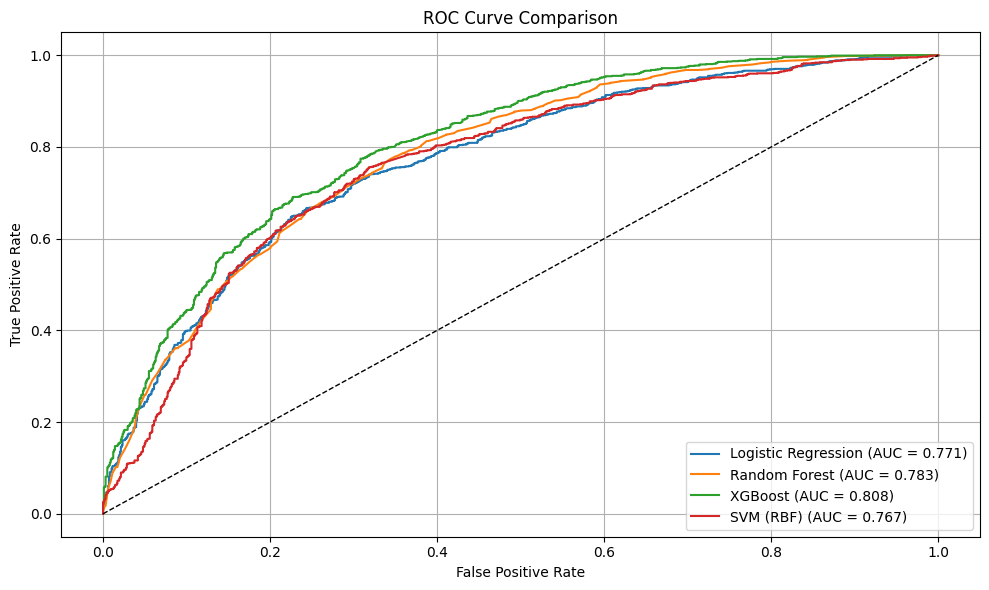

In [117]:
# Plot ROC curves
def pos_proba(p):
    """Ensure we use the positive-class probability (handle [n,2] arrays)."""
    p = np.asarray(p)
    return p[:, 1] if p.ndim == 2 and p.shape[1] == 2 else p

# Ensure these are positive-class scores/probabilities
p_lr  = pos_proba(y_proba_lr)
p_rf  = pos_proba(y_proba_rf)
p_xgb = pos_proba(y_proba_xgb)
p_svm = pos_proba(y_proba_svm)  # SVM must be trained with probability=True (or use decision_function)

# ROC points
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, p_lr)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, p_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, p_xgb)
fpr_svm, tpr_svm, _ = roc_curve(y_test, p_svm)

# AUCs
auc_lr  = roc_auc_score(y_test, p_lr)
auc_rf  = roc_auc_score(y_test, p_rf)
auc_xgb = roc_auc_score(y_test, p_xgb)
auc_svm = roc_auc_score(y_test, p_svm)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(fpr_lr,  tpr_lr,  label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf,  tpr_rf,  label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (RBF) (AUC = {auc_svm:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


The ROC Curve in the image compares the performance of Four models: Logistic Regression, Random Forest, SVM, and XGBoost. The curve shows how well each model separates successful startups from unsuccessful ones. A higher curve means better performance. XGBoost has the highest curve, meaning it predicts the outcomes more accurately. Logistic Regression and Random Forest also perform well but not as strong as XGBoost. This graph helps us choose the best model visually.

# **Optimize the Models**

In [118]:
# Basic cleaning and target setup
# Drop non-numeric or identifier columns (e.g. names, org links, etc.)
drop_cols = df_bin.select_dtypes(include=['object', 'datetime64']).columns
X = df_bin.drop(columns=['success_binary']+ list(drop_cols))
y = df_bin['success_binary']

# Impute any remaining missing values
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [119]:
# Logistic Regression with GridSearch
lr_params = {
    'C': [0.01, 0.1, 1, 10], # Inverse of Regularization Strength -(prevents overfitting)
    'penalty': ['l1', 'l2'], #This helps control model complexity. l1- lasso- remove irrelevant features  l2-ridge-shrinks coefficients but doesn’t eliminate them)
    'solver': ['liblinear'],
    'class_weight': ['balanced']
}
lr_model = GridSearchCV(LogisticRegression(), lr_params, cv=5, scoring='roc_auc')
lr_model.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10], 'class_weight': ['balanced'],
                         'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
             scoring='roc_auc')

In [120]:
# Random Forest with GridSearch
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}
rf_model = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='roc_auc')
rf_model.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'class_weight': ['balanced'], 'max_depth': [5, 10],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='roc_auc')

In [121]:
# XGBoost with GridSearch
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 1],
    'colsample_bytree': [0.7, 1]
}
xgb_model_cv = GridSearchCV(XGBClassifier(eval_metric='logloss'), xgb_params, cv=3, scoring='roc_auc')
xgb_model_cv.fit(X_train_scaled, y_train)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'colsample_bytree': [0.7, 1],
                         'learning_rate': [0.01, 0.1, 0.3],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200],
                         'subsample': [0.7, 1]},
             scoring='roc_auc')

In [122]:
# SVM with GridSearch
svm_params = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf']
}
svm_model = GridSearchCV(SVC(probability=True), svm_params, cv=3, scoring='roc_auc')
svm_model.fit(X_train_scaled, y_train)

GridSearchCV(cv=3, estimator=SVC(probability=True),
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['rbf']},
             scoring='roc_auc')

In [123]:
# Voting Classifier Ensemble
ensemble = VotingClassifier(estimators=[
    ('lr', lr_model.best_estimator_),
    ('rf', rf_model.best_estimator_),
    ('xgb', xgb_model_cv.best_estimator_),
    ('svm', svm_model.best_estimator_)
], voting='soft')
ensemble.fit(X_train_scaled, y_train)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(C=0.1, class_weight='balanced',
                                                 solver='liblinear')),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     max_depth=10,
                                                     min_samples_split=5,
                                                     n_estimators=200,
                                                     random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytr...
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('svm', SVC(C=1, probability=True))],
                 voting='soft')

In [124]:
def evaluate_models_sequential(models, X_test_scaled, y_test, *,
                               labels=None,
                               save_plots=False,
                               dpi=200):

    def _positive_scores(model, X):
        # Prefer predict_proba if available
        if hasattr(model, "predict_proba"):
            return model.predict_proba(X)[:, 1]
        # Fallback to decision_function (scale to [0,1] so ROC AUC works)
        if hasattr(model, "decision_function"):
            s = model.decision_function(X)
            s_min, s_max = np.min(s), np.max(s)
            if s_max == s_min:
                return np.zeros_like(s, dtype=float)
            return (s - s_min) / (s_max - s_min)
        # Last resort: use hard predictions (ROC AUC will be less informative)
        return model.predict(X).astype(float)

    labels = np.unique(y_test) if labels is None else labels

    summary_rows, cms, reports = [], {}, {}

    for name, model in models.items():
        # --- predictions & scores ---
        y_pred = model.predict(X_test_scaled)
        y_scores = _positive_scores(model, X_test_scaled)

        # --- metrics ---
        acc = accuracy_score(y_test, y_pred)
        try:
            roc = roc_auc_score(y_test, y_scores)
        except ValueError:
            roc = np.nan  # e.g., only one class present

        # --- print metrics one-by-one ---
        print(f"\n{name}")
        print("-" * len(name))
        print(f"Accuracy     : {acc:.4f}")
        print(f"ROC AUC      : {('%.4f' % roc) if not np.isnan(roc) else 'NA'}")
        print("\nClassification Report")
        print(classification_report(y_test, y_pred, digits=4, zero_division=0))

        # --- confusion matrix (numeric + plot) ---
        cm = confusion_matrix(y_test, y_pred, labels=labels)
        cms[name] = cm
        reports[name] = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

        fig, ax = plt.subplots(figsize=(5.5, 4.5))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax, colorbar=False)
        ax.set_title(f"Confusion Matrix — {name}")
        fig.tight_layout()
        if save_plots:
            fname = f"cm_{name.replace(' ', '_').lower()}.png"
            fig.savefig(fname, dpi=dpi)
        plt.show()  # show immediately for this model

        # --- collect for summary dataframe ---
        summary_rows.append({"Model": name, "Accuracy": acc, "ROC AUC": roc})

    results_df = pd.DataFrame(summary_rows).sort_values("ROC AUC", ascending=False)
    print("\n=== Summary (sorted by ROC AUC) ===")
    print(results_df.to_string(index=False))
    return results_df, cms, reports



Logistic Regression
-------------------
Accuracy     : 0.6990
ROC AUC      : 0.7791

Classification Report
              precision    recall  f1-score   support

         0.0     0.6329    0.7818    0.6995       999
         1.0     0.7809    0.6317    0.6984      1230

    accuracy                         0.6990      2229
   macro avg     0.7069    0.7067    0.6990      2229
weighted avg     0.7146    0.6990    0.6989      2229



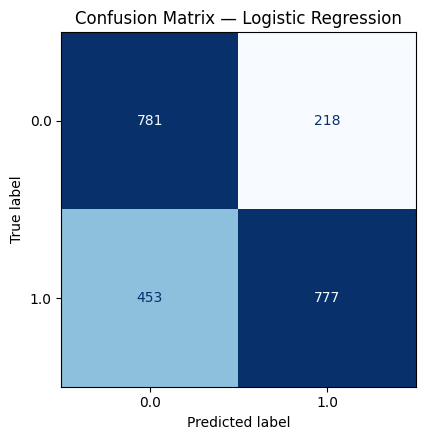


Random Forest
-------------
Accuracy     : 0.7411
ROC AUC      : 0.8170

Classification Report
              precision    recall  f1-score   support

         0.0     0.7131    0.7067    0.7099       999
         1.0     0.7635    0.7691    0.7663      1230

    accuracy                         0.7411      2229
   macro avg     0.7383    0.7379    0.7381      2229
weighted avg     0.7409    0.7411    0.7410      2229



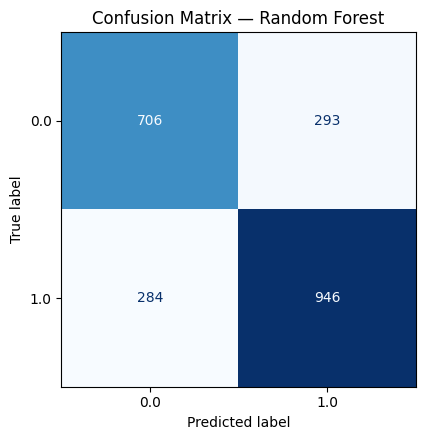


XGBoost
-------
Accuracy     : 0.7497
ROC AUC      : 0.8242

Classification Report
              precision    recall  f1-score   support

         0.0     0.7486    0.6647    0.7041       999
         1.0     0.7504    0.8187    0.7830      1230

    accuracy                         0.7497      2229
   macro avg     0.7495    0.7417    0.7436      2229
weighted avg     0.7496    0.7497    0.7477      2229



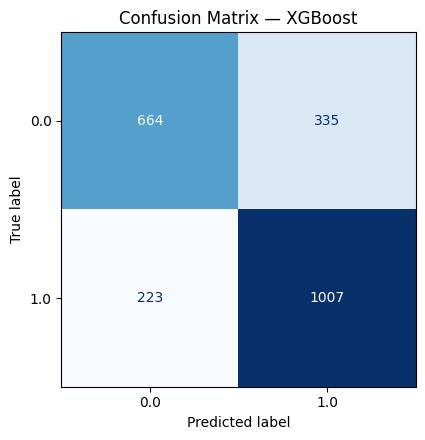


SVM
---
Accuracy     : 0.7331
ROC AUC      : 0.7883

Classification Report
              precision    recall  f1-score   support

         0.0     0.7131    0.6767    0.6944       999
         1.0     0.7479    0.7789    0.7630      1230

    accuracy                         0.7331      2229
   macro avg     0.7305    0.7278    0.7287      2229
weighted avg     0.7323    0.7331    0.7323      2229



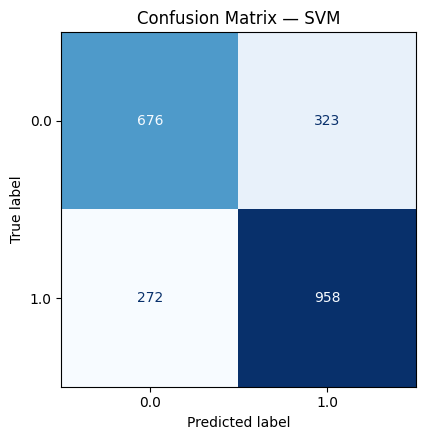


Ensemble
--------
Accuracy     : 0.7434
ROC AUC      : 0.8161

Classification Report
              precision    recall  f1-score   support

         0.0     0.7176    0.7047    0.7111       999
         1.0     0.7636    0.7748    0.7692      1230

    accuracy                         0.7434      2229
   macro avg     0.7406    0.7398    0.7401      2229
weighted avg     0.7430    0.7434    0.7431      2229



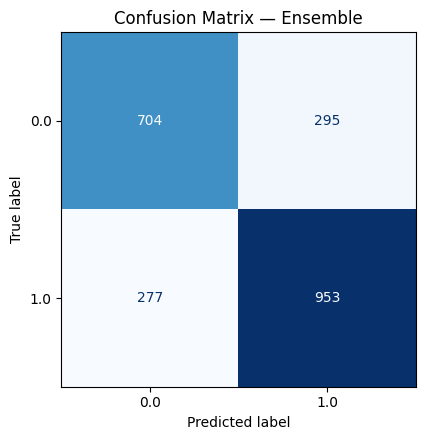


=== Summary (sorted by ROC AUC) ===
              Model  Accuracy  ROC AUC
            XGBoost  0.749664 0.824242
      Random Forest  0.741140 0.816982
           Ensemble  0.743383 0.816051
                SVM  0.733064 0.788267
Logistic Regression  0.698968 0.779073


In [125]:
models = {
    'Logistic Regression': lr_model.best_estimator_,
    'Random Forest': rf_model.best_estimator_,
    'XGBoost': xgb_model_cv.best_estimator_,
    'SVM': svm_model.best_estimator_,
    'Ensemble': ensemble
}

results_df, cms, reports = evaluate_models_sequential(
    models, X_test_scaled, y_test, save_plots=False
)


In [126]:
# Evaluate models
models = {
    'Logistic Regression': lr_model.best_estimator_,
    'Random Forest': rf_model.best_estimator_,
    'XGBoost': xgb_model_cv.best_estimator_,
    'SVM (RBF)': svm_model.best_estimator_,
    'Ensemble': ensemble
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    cv_roc = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc').mean()
    results.append({'Model': name, 'Accuracy': acc * 100, 'ROC AUC': roc, 'CV ROC AUC': cv_roc})

# Convert to DataFrame and display
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,ROC AUC,CV ROC AUC
0,Logistic Regression,69.896815,0.779073,0.778896
1,Random Forest,74.113952,0.816982,0.810838
2,XGBoost,74.966353,0.824242,0.817152
3,SVM (RBF),73.306415,0.788267,0.783689
4,Ensemble,74.338268,0.816051,0.812052


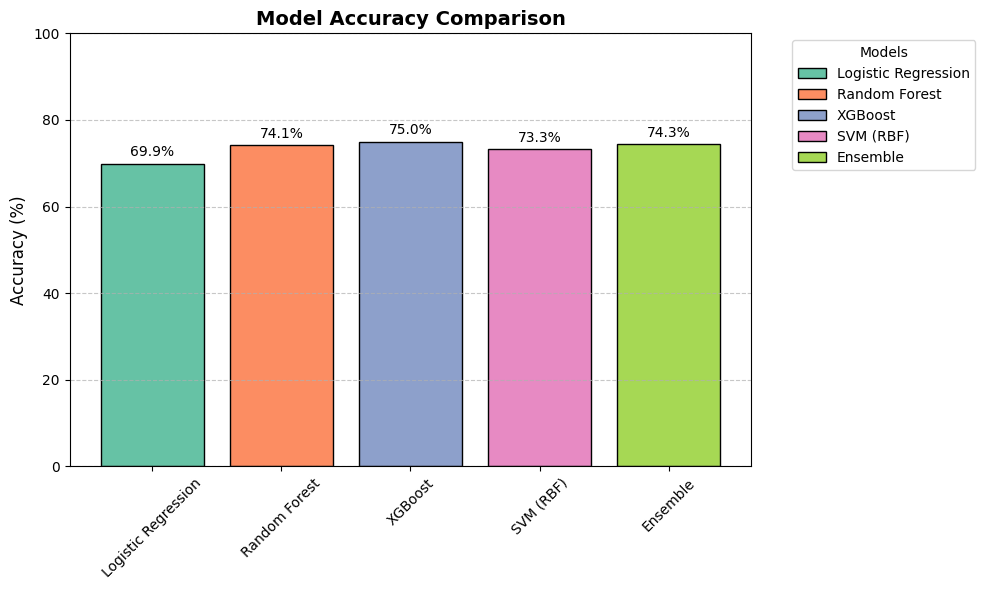

In [127]:
palette = sns.color_palette("Set2", len(results_df))
plt.figure(figsize=(10, 6))
bars = plt.bar(results_df['Model'], results_df['Accuracy'], color=palette, edgecolor='black', label=results_df['Model'])
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 100)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height + 1, f'{height:.1f}%', ha='center', va='bottom', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Models')
plt.tight_layout()
plt.show()

In [128]:
# --- Save the trained model ---
with open("xgb_model_retrained.pkl", "wb") as f:
    pickle.dump(xgb_model, f)
print("Saved Model Type:", type(xgb_model))

# --- Save the fitted scaler ---
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Saved Model Type:", type(scaler))


Saved Model Type: <class 'xgboost.sklearn.XGBClassifier'>
Saved Model Type: <class 'sklearn.preprocessing._data.StandardScaler'>
